# MedSAM Evaluation on Brain Tumor Validation Dataset

In [ ]:
!git clone https://github.com/bowang-lab/MedSAM.git
%cd MedSAM
!sed -i '/entry_points/d' setup.py
!pip install . --no-deps


Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Counting objects: 100% (354/354), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 967 (delta 286), reused 237 (delta 237), pack-reused 613 (from 2)
Receiving objects: 100% (967/967), 62.89 MiB | 17.01 MiB/s, done.
Resolving deltas: 100% (479/479), done.
/content/MedSAM
Processing /content/MedSAM
  Preparing metadata (setup.py) ... done
  Created wheel for medsam: filename=medsam-0.0.1-py3-none-any.whl size=37340 sha256=a9947140a1376d342cefd24dc0b9ed51a1b404f1e4d2bf731c6633b4c3156393
  Stored in directory: /tmp/pip-ephem-wheel-cache-bum55p00/wheels/60/54/d5/005bcb04f06ecf0f5fc9b762990af2f557aefc41710b197db0
Successfully built medsam


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

VAL_PATH_SMALL = "/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation_Small_Manual"
VAL_PATH = "/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation"


Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import nibabel as nib
from skimage import transform, measure
import torch
import torch.nn.functional as F
from segment_anything import sam_model_registry
from sklearn.metrics import f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
# Download checkpoint and load MedSAM
!wget -O medsam_vit_b.pth https://zenodo.org/records/10689643/files/medsam_vit_b.pth

ckpt_path = "medsam_vit_b.pth"
medsam_model = sam_model_registry["vit_b"](checkpoint=ckpt_path).to(device)
medsam_model.eval()


--2025-05-30 21:39:29--  https://zenodo.org/records/10689643/files/medsam_vit_b.pth
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.48.194, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375049145 (358M) [application/octet-stream]
Saving to: ‘medsam_vit_b.pth’

medsam_vit_b.pth    100%[===================>] 357.67M  11.7MB/s    in 21s     

2025-05-30 21:39:51 (17.0 MB/s) - ‘medsam_vit_b.pth’ saved [375049145/375049145]



Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [ ]:
@torch.no_grad()
def medsam_inference(medsam_model, img_tensor, box_1024, H, W):
    embedding = medsam_model.image_encoder(img_tensor)
    box_torch = torch.tensor(box_1024, dtype=torch.float, device=device)
    box_torch = box_torch[None, None, :]
    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None, boxes=box_torch, masks=None
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=embedding,
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_embeddings,
        dense_prompt_embeddings=dense_embeddings,
        multimask_output=False,
    )
    low_res_pred = torch.sigmoid(low_res_logits)
    low_res_pred = F.interpolate(low_res_pred, size=(H, W), mode="bilinear", align_corners=False)
    return (low_res_pred.squeeze().cpu().numpy() > 0.5).astype(np.uint8)


In [ ]:
dice_scores = []
f1_scores = []
specificities = []
sensitivities = []
case_ids = []
val_interval = 1  # or change this to match how often you evaluate (e.g., every 5 epochs)


for case in sorted(os.listdir(VAL_PATH_SMALL)):
    folder = os.path.join(VAL_PATH_SMALL, case)
    img_path = os.path.join(folder, f"{case}-t1c.nii.gz")
    mask_path = os.path.join(folder, f"{case}-seg.nii.gz")

    if not os.path.exists(img_path) or not os.path.exists(mask_path):
        continue

    img = nib.load(img_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    # Middle slice
    z = img.shape[2] // 2
    img_slice = img[:, :, z]
    mask_slice = mask[:, :, z]

    # Normalize + convert to 3 channels
    img_norm = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
    img_rgb = np.repeat(img_norm[:, :, None], 3, axis=-1)
    H, W = img_rgb.shape[:2]

    # Resize and tensor
    img_resized = transform.resize(img_rgb, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True)
    img_tensor = torch.tensor(img_resized).float().permute(2, 0, 1).unsqueeze(0).to(device)

    # Create bounding box from mask
    if mask_slice.max() == 0:
        continue
    region = measure.regionprops(mask_slice.astype(int))[0].bbox
    box = np.array([region[1], region[0], region[3], region[2]])
    box = box / np.array([W, H, W, H]) * 1024

    pred_mask = medsam_inference(medsam_model, img_tensor, box, H, W)

    gt = mask_slice.astype(np.uint8)
    pred = pred_mask.astype(np.uint8)

    intersection = np.logical_and(gt, pred).sum()
    union = gt.sum() + pred.sum()
    dice = 2 * intersection / union if union > 0 else 1.0
    f1 = f1_score((gt > 0).flatten(), (pred > 0).flatten(), average="binary")


    # Flatten and binarize
    pred_flat = (pred > 0).flatten()
    gt_flat = (gt > 0).flatten()

    # Compute metrics
    TP = np.logical_and(pred_flat == 1, gt_flat == 1).sum()
    TN = np.logical_and(pred_flat == 0, gt_flat == 0).sum()
    FP = np.logical_and(pred_flat == 1, gt_flat == 0).sum()
    FN = np.logical_and(pred_flat == 0, gt_flat == 1).sum()

    specificity = TN / (TN + FP + 1e-8)
    sensitivity = TP / (TP + FN + 1e-8)

    f1 = f1_score(gt_flat, pred_flat, average="binary")
    intersection = np.logical_and(pred, gt).sum()
    union = pred.sum() + gt.sum()
    dice = 2 * intersection / union if union > 0 else 1.0

    # Append to lists
    dice_scores.append(dice)
    f1_scores.append(f1)
    specificities.append(specificity)
    sensitivities.append(sensitivity)
    case_ids.append(case)



##Scores

In [ ]:
print(f"Dice Score (avg):       {np.mean(dice_scores):.4f}")
print(f"F1 Score (avg):         {np.mean(f1_scores):.4f}")
print(f"Sensitivity (avg):      {np.mean(sensitivities):.4f}")
print(f"Specificity (avg):      {np.mean(specificities):.4f}")

Dice Score (avg):       0.2614
F1 Score (avg):         0.4317
Sensitivity (avg):      0.3542
Specificity (avg):      0.9977


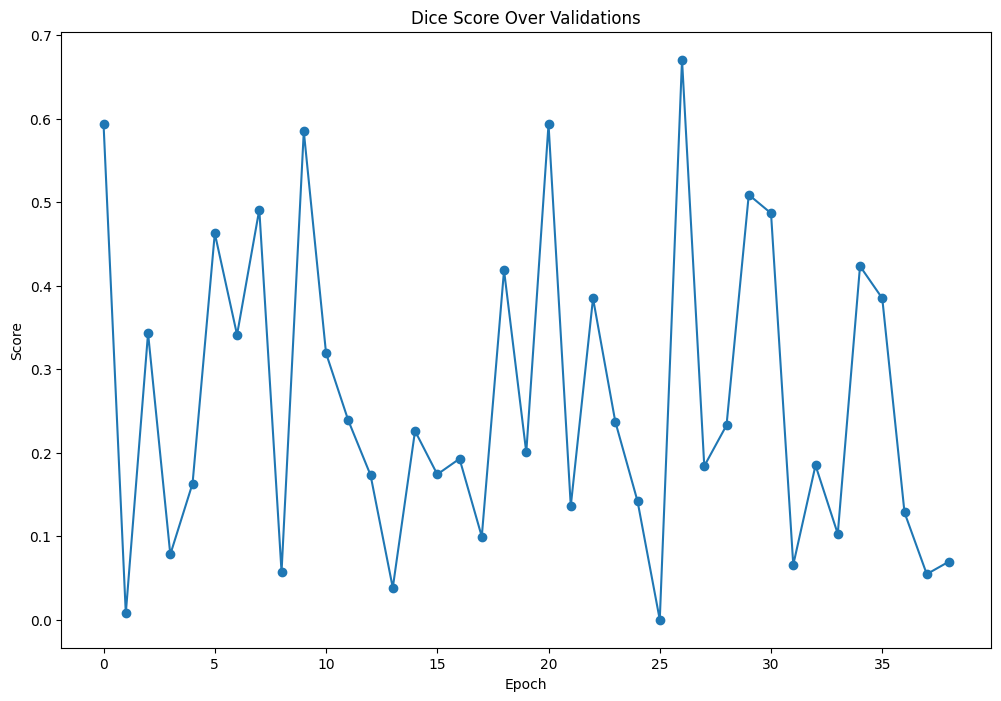

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

epochs = [val_interval * i for i in range(len(dice_scores))]
plt.plot(epochs, dice_scores, marker='o', label='Dice Score')
plt.title("Dice Score Over Validations")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.grid = True
plt.show()


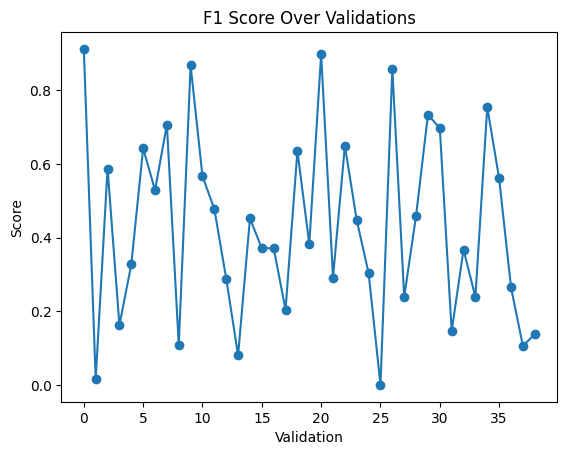

In [ ]:
plt.plot(epochs, f1_scores, marker='o', label='F1 Score')
plt.title("F1 Score Over Validations")
plt.xlabel("Validation")
plt.ylabel("Score")
plt.grid = True
plt.show()

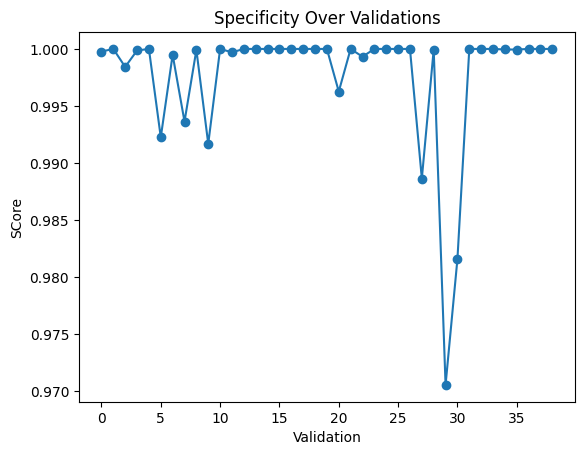

In [ ]:
plt.plot(epochs, specificities, marker='o', label='Specificity')
plt.title("Specificity Over Validations")
plt.xlabel("Validation")
plt.ylabel("SCore")
plt.grid = True
plt.show()

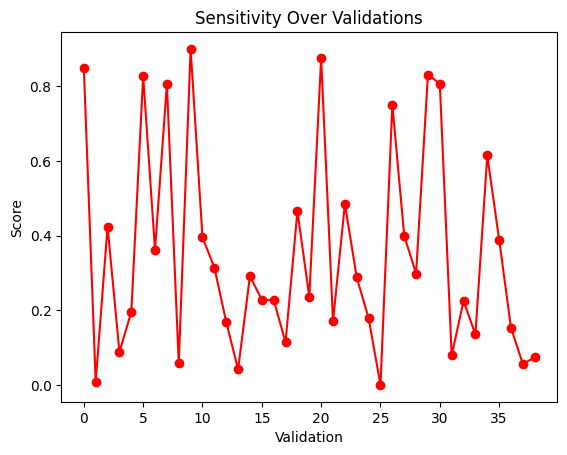

In [ ]:
plt.plot(epochs, sensitivities, marker='o', label='Sensitivity Score', color = 'red')
plt.title("Sensitivity Over Validations")
plt.xlabel("Validation")
plt.ylabel("Score")
plt.grid = True
plt.show()

Text(0, 0.5, 'Frequency')

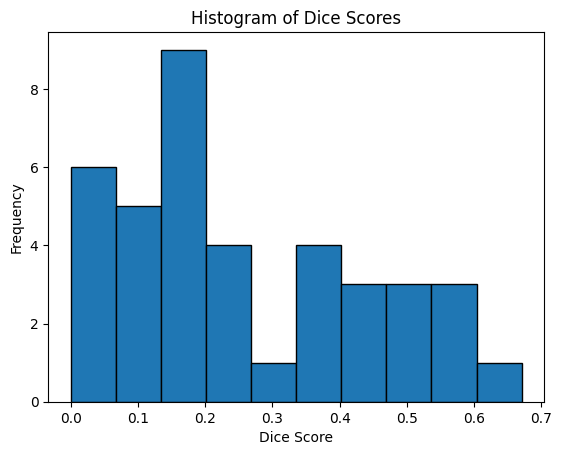

In [ ]:
plt.hist(dice_scores, bins=10, edgecolor='black')
plt.title("Histogram of Dice Scores")
plt.xlabel("Dice Score")
plt.ylabel("Frequency")


Text(0, 0.5, 'Dice Score')

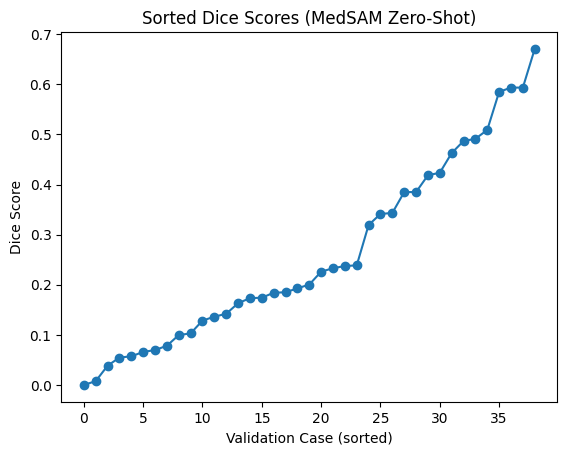

In [ ]:
sorted_scores = sorted(dice_scores)
plt.plot(sorted_scores, marker='o')
plt.title("Sorted Dice Scores (MedSAM Zero-Shot)")
plt.xlabel("Validation Case (sorted)")
plt.ylabel("Dice Score")


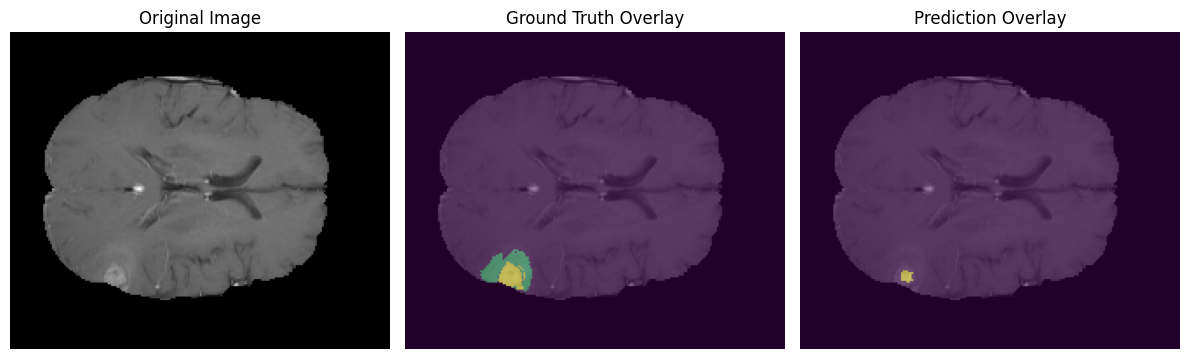

In [ ]:
import random
import matplotlib.pyplot as plt

# Choose a random validation case
case_list = sorted(os.listdir(VAL_PATH_SMALL))
case = random.choice(case_list)
folder = os.path.join(VAL_PATH_SMALL, case)
img_path = os.path.join(folder, f"{case}-t1c.nii.gz")
mask_path = os.path.join(folder, f"{case}-seg.nii.gz")

img = nib.load(img_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

# Middle slice
z = img.shape[2] // 2
img_slice = img[:, :, z]
mask_slice = mask[:, :, z]

# Normalize image
img_norm = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
img_rgb = np.repeat(img_norm[:, :, None], 3, axis=-1)
H, W = img_rgb.shape[:2]

# Resize and tensorize
img_resized = transform.resize(img_rgb, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True)
img_tensor = torch.tensor(img_resized).float().permute(2, 0, 1).unsqueeze(0).to(device)

# Bounding box from mask
region = measure.regionprops(mask_slice.astype(int))[0].bbox
box = np.array([region[1], region[0], region[3], region[2]])
box = box / np.array([W, H, W, H]) * 1024

# Inference
pred_mask = medsam_inference(medsam_model, img_tensor, box, H, W)

# Visualization
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(img_norm, cmap='gray')
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(img_norm, cmap='gray')
axs[1].imshow(mask_slice, alpha=0.5, cmap='viridis')
axs[1].set_title("Ground Truth Overlay")
axs[1].axis('off')

axs[2].imshow(img_norm, cmap='gray')
axs[2].imshow(pred_mask, alpha=0.5, cmap='viridis')
axs[2].set_title("Prediction Overlay")
axs[2].axis('off')

plt.tight_layout()
plt.show()


##Bounding Box Training

In [ ]:
!pip install nibabel


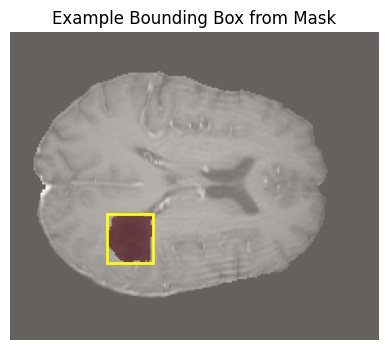

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Define a function to generate bounding boxes from binary masks
def get_bounding_box(mask: np.ndarray):
    """Returns bounding box [x_min, y_min, x_max, y_max] from a binary mask."""
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any() or not cols.any():
        return None  # No object in mask
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]
    return [x_min, y_min, x_max, y_max]

# Visualization function
def show_image_with_bbox(image_slice, mask_slice, bbox, title="Bounding Box Overlay"):
    plt.figure(figsize=(8, 4))
    plt.imshow(image_slice, cmap="gray")
    plt.imshow(mask_slice, cmap="Reds", alpha=0.4)
    if bbox:
        x_min, y_min, x_max, y_max = bbox
        plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                          edgecolor='yellow', facecolor='none', linewidth=2))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Example usage on one image + mask (replace paths with yours)
example_image_path = "/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation_Small_Manual/BraTS-GLI-00101-000/BraTS-GLI-00101-000-t1c.nii.gz"
example_mask_path = "/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation_Small_Manual/BraTS-GLI-00101-000/BraTS-GLI-00101-000-seg.nii.gz"

image = nib.load(example_image_path).get_fdata()
mask = nib.load(example_mask_path).get_fdata()

# Take a middle slice for visualization
mid = image.shape[2] // 2
image_slice = image[:, :, mid]
mask_slice = (mask[:, :, mid] > 0).astype(np.uint8)

bbox = get_bounding_box(mask_slice)
show_image_with_bbox(image_slice, mask_slice, bbox, "Example Bounding Box from Mask")

# 🔧 Dataset Splitting and Bounding Box Evaluation
We will split the dataset into training and validation sets, generate bounding boxes, and evaluate MedSAM on the validation set using Dice, F1, Sensitivity, and Specificity metrics.

In [ ]:
from pathlib import Path

In [ ]:
# Point to the MedSAM weights folder you mentioned.
MEDSAM_CKPT = "/content/drive/MyDrive/MedSAM/medsam_vit_b.pth"
assert Path(MEDSAM_CKPT).is_file(), "Checkpoint not found — check the path!"

In [ ]:
from segment_anything import sam_model_registry, SamPredictor

# register and load the ViT‑B backbone with MedSAM weights
sam = sam_model_registry["vit_b"](checkpoint=MEDSAM_CKPT)
sam = sam.cuda().eval()                              # GPU + inference mode
predictor = SamPredictor(sam)                        # optional helper


In [ ]:
# ─── NEW data‑set class (unique name) ─────────────────────────
import os, numpy as np, torch, nibabel as nib
from pathlib import Path
from torch.utils.data import Dataset

def mask_to_bbox(mask2d, pad=8):
    ys, xs = np.where(mask2d)
    if xs.size == 0:
        h, w = mask2d.shape
        return torch.tensor([[0, 0, w - 1, h - 1]], dtype=torch.float32)
    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()
    y1, y2 = max(0, y1 - pad), min(mask2d.shape[0] - 1, y2 + pad)
    x1, x2 = max(0, x1 - pad), min(mask2d.shape[1] - 1, x2 + pad)
    return torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)

class BrainTumorSliceDatasetV2(Dataset):
    modality_patterns = ["*-t1c.nii.gz", "*-t1n.nii.gz",
                         "*-t2f.nii.gz", "*-t2w.nii.gz"]
    mask_pattern     = "*-seg.nii.gz"

    def __init__(self, root_dir, slice_strategy="middle"):
        self.root_dir = Path(root_dir)
        self.case_triplets = []                    # (dir, img_file, mask_file)
        for d in sorted(self.root_dir.iterdir()):
            if not d.is_dir():
                continue
            mask_file = next(d.glob(self.mask_pattern), None)
            img_file  = None
            for pat in self.modality_patterns:
                img_file = next(d.glob(pat), None)
                if img_file:
                    break
            if mask_file and img_file:
                self.case_triplets.append((d, img_file, mask_file))
        self.slice_strategy = slice_strategy

    def __len__(self):
        return len(self.case_triplets)

    def __getitem__(self, idx):
        case_dir, img_path, mask_path = self.case_triplets[idx]
        img_nii  = nib.load(img_path).get_fdata()
        mask_nii = nib.load(mask_path).get_fdata()

        # choose slice
        if self.slice_strategy == "middle":
            k = img_nii.shape[2] // 2
        else:
            non_empty = np.where(mask_nii.sum(axis=(0, 1)) > 0)[0]
            k = np.random.choice(non_empty) if non_empty.size else img_nii.shape[2] // 2

        img  = img_nii[:, :, k]
        mask = (mask_nii[:, :, k] > 0).astype(np.uint8)

        # normalise
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # bbox
        box = mask_to_bbox(mask)

        return (torch.from_numpy(img).unsqueeze(0).float(),
                torch.from_numpy(mask).unsqueeze(0).float(),
                box)


In [ ]:
dataset = BrainTumorSliceDatasetV2(VAL_PATH_SMALL, slice_strategy="middle")
print("Dataset length (should be 44):", len(dataset))

# sanity‑print first entry
img, msk, box = dataset[0]
print("Image shape :", img.shape)
print("Mask shape  :", msk.shape)
print("BBox tensor :", box)


Dataset length (should be 44): 43
Image shape : torch.Size([1, 182, 218])
Mask shape  : torch.Size([1, 182, 218])
BBox tensor : tensor([[ 49.,  99.,  92., 144.]])


In [ ]:
from pathlib import Path

first_case = next(iter(sorted(Path(VAL_PATH_SMALL).iterdir())))  # Path object
print("Folder :", first_case.name)
print("Files  :", list(first_case.iterdir()))


Folder : BraTS-GLI-00101-000
Files  : [PosixPath('/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation_Small_Manual/BraTS-GLI-00101-000/BraTS-GLI-00101-000-seg.nii.gz'), PosixPath('/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation_Small_Manual/BraTS-GLI-00101-000/BraTS-GLI-00101-000-t1c.nii.gz'), PosixPath('/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation_Small_Manual/BraTS-GLI-00101-000/BraTS-GLI-00101-000-t1n.nii.gz'), PosixPath('/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation_Small_Manual/BraTS-GLI-00101-000/BraTS-GLI-00101-000-t2f.nii.gz'), PosixPath('/content/drive/MyDrive/CS235 Final Proj Data/Data/Validation_Small_Manual/BraTS-GLI-00101-000/BraTS-GLI-00101-000-t2w.nii.gz')]


In [ ]:
def compute_metrics(pred: np.ndarray, gt: np.ndarray):
    """
    pred, gt : boolean masks (H×W)
    Returns  : dice, f1, specificity, sensitivity  (floats in [0,1])
    """
    # flatten to 1‑D for simple counting
    pred_f = pred.reshape(-1)
    gt_f   = gt.reshape(-1)

    tp = np.logical_and(pred_f, gt_f).sum()
    fp = np.logical_and(pred_f, np.logical_not(gt_f)).sum()
    fn = np.logical_and(np.logical_not(pred_f), gt_f).sum()
    tn = np.logical_and(np.logical_not(pred_f), np.logical_not(gt_f)).sum()

    dice        = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 1.0
    f1          = f1_score(gt_f, pred_f, zero_division=1)
    specificity = tn / (tn + fp) if (tn + fp) else 1.0
    sensitivity = tp / (tp + fn) if (tp + fn) else 1.0

    return dice, f1, specificity, sensitivity

In [ ]:
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader

val_loader = DataLoader(dataset, batch_size=1, shuffle=False)

# your validation loop here...


sam.eval()
history = {"dice": [], "f1": [], "spec": [], "sens": []}

with torch.no_grad():
    for img, msk, box in tqdm(val_loader):          # B == 1

        # ----- prepare inputs for SamPredictor -----
        # 1‑channel (H,W) → 3‑channel uint8 (H,W,3) in [0,255]
        img_np = img[0, 0].cpu().numpy()
        img_rgb = np.stack([img_np]*3, axis=-1)        # repeat to 3‑ch
        img_rgb = (img_rgb * 255).astype(np.uint8)

        predictor.set_image(img_rgb)
        masks, _, _ = predictor.predict(
            box=box[0].cpu().numpy(),            # (4,) xyxy
            multimask_output=False               # single best mask
        )
        pred_np = masks[0]                       # boolean H×W

        gt_np   = msk[0, 0].cpu().numpy().astype(bool)

        dice, f1, spec, sens = compute_metrics(pred_np, gt_np)
        history["dice"].append(dice)
        history["f1"].append(f1)
        history["spec"].append(spec)
        history["sens"].append(sens)


100%|██████████| 43/43 [00:26<00:00,  1.64it/s]


In [ ]:
# --- print final validation scores ----------------------------------------
def print_final_scores():
    if "history" in globals():
        # keys used in the multi‑epoch logger block
        metrics = ["dice", "f1", "spec", "sens"]
        finals  = {m: history[m][-1] for m in metrics}
    elif "epoch_metrics" in globals():
        # keys used in the simpler single‑dict example
        metrics = ["dice", "f1", "specificity", "sensitivity"]
        finals  = {m: epoch_metrics[m][-1] for m in metrics}
    else:
        print("❗ No metrics dictionary (history / epoch_metrics) found.")
        return

    print("\n🟢 Final validation scores")
    for k, v in finals.items():
        print(f"  {k.capitalize():<12}: {v:.4f}")

print_final_scores()



🟢 Final validation scores
  Dice        : 0.7008
  F1          : 0.7008
  Spec        : 0.9523
  Sens        : 0.7664


In [ ]:
print(epoch_metrics.keys())
print(history.keys() if 'history' in globals() else "history not defined")


dict_keys(['dice', 'f1', 'specificity', 'sensitivity'])
dict_keys(['dice', 'f1', 'spec', 'sens'])


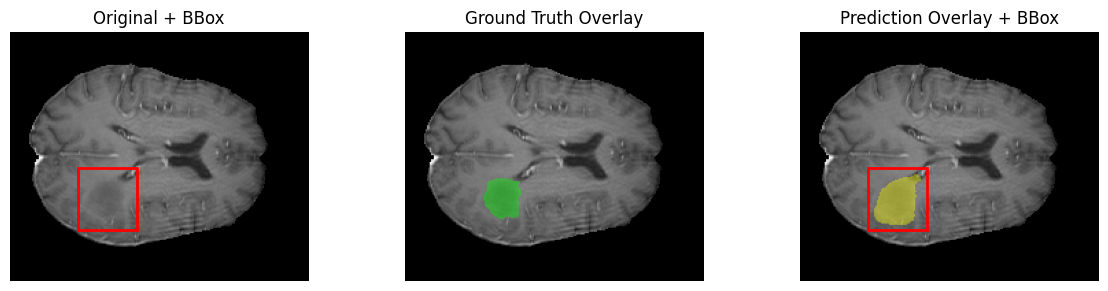

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

# ---------- pick a validation sample ----------
idx = 0                                           # change to view another case
img_t, msk_t, box_t = dataset[idx]                # tensors from __getitem__

img_np  = img_t[0].numpy()                        # H×W float32 in [0,1]
msk_np  = msk_t[0].numpy().astype(bool)           # H×W bool
bbox_xyxy = box_t[0].numpy()                      # [x1, y1, x2, y2]  float32

# ---------- run MedSAM predictor ---------------
img_rgb = (np.stack([img_np]*3, -1) * 255).astype(np.uint8)
predictor.set_image(img_rgb)
pred_mask, _, _ = predictor.predict(
    box=bbox_xyxy,
    multimask_output=False
)
pred_np = pred_mask[0]                            # H×W bool

# ---------- helper to overlay masks ------------
def overlay(img, mask, color=(1,1,0), alpha=0.4):
    img_rgb = np.stack([img]*3, -1)
    for c in range(3):
        img_rgb[..., c] = np.where(
            mask,
            img_rgb[..., c]*(1-alpha) + alpha*color[c],
            img_rgb[..., c]
        )
    return img_rgb

gt_overlay   = overlay(img_np,  msk_np,  color=(0,1,0))   # green
pred_overlay = overlay(img_np, pred_np,  color=(1,1,0))   # yellow

# ---------- plot with bounding box -------------
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# (1) original slice + bbox
axes[0].imshow(img_np, cmap='gray')
x1, y1, x2, y2 = bbox_xyxy
rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                         linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title("Original + BBox")

# (2) GT overlay
axes[1].imshow(gt_overlay)
axes[1].set_title("Ground Truth Overlay")

# (3) Prediction overlay + bbox (optional)
axes[2].imshow(pred_overlay)
axes[2].add_patch(
    patches.Rectangle((x1, y1), x2-x1, y2-y1,
                      linewidth=2, edgecolor='red', facecolor='none')
)
axes[2].set_title("Prediction Overlay + BBox")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
print("epoch_metrics keys →", epoch_metrics.keys()       if 'epoch_metrics' in globals() else "epoch_metrics missing")
print("history keys       →", history.keys()             if 'history'       in globals() else "history missing")

if 'epoch_metrics' in globals():
    for k in epoch_metrics:
        print(f"{k:12s}: {len(epoch_metrics[k])} entries")
if 'history' in globals():
    for k in history:
        print(f"{k:12s}: {len(history[k])} entries")


epoch_metrics keys → dict_keys(['dice', 'f1', 'specificity', 'sensitivity'])
history keys       → dict_keys(['dice', 'f1', 'spec', 'sens'])
dice        : 0 entries
f1          : 0 entries
specificity : 0 entries
sensitivity : 0 entries
dice        : 43 entries
f1          : 43 entries
spec        : 43 entries
sens        : 43 entries


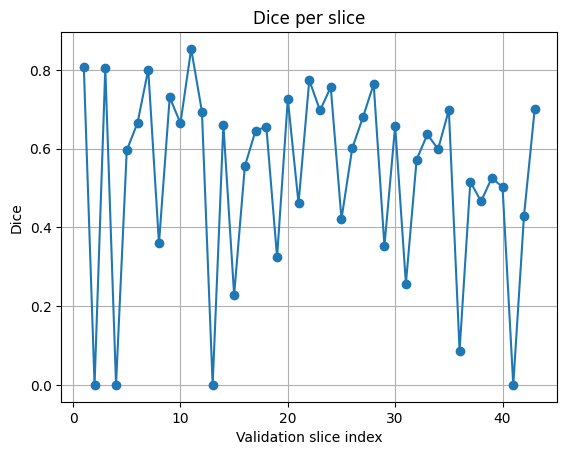

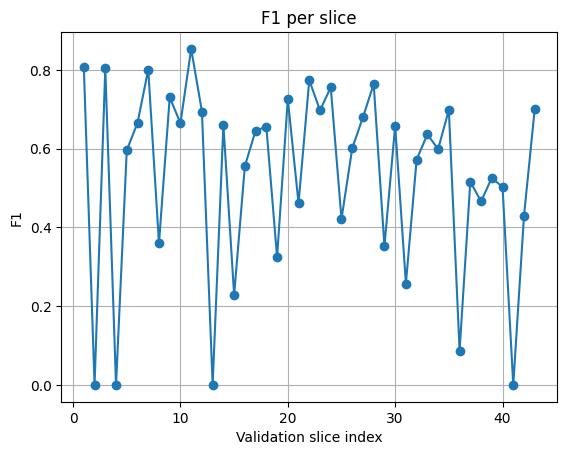

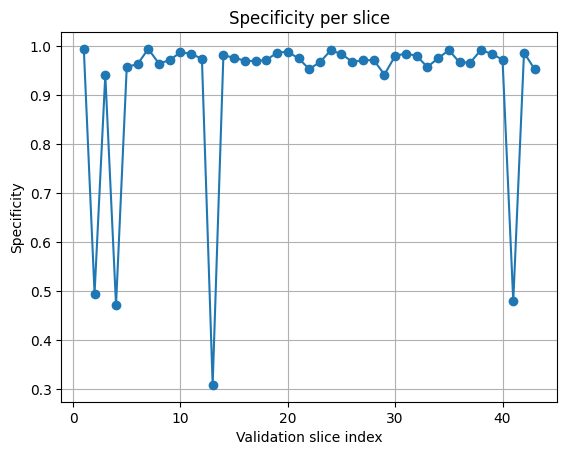

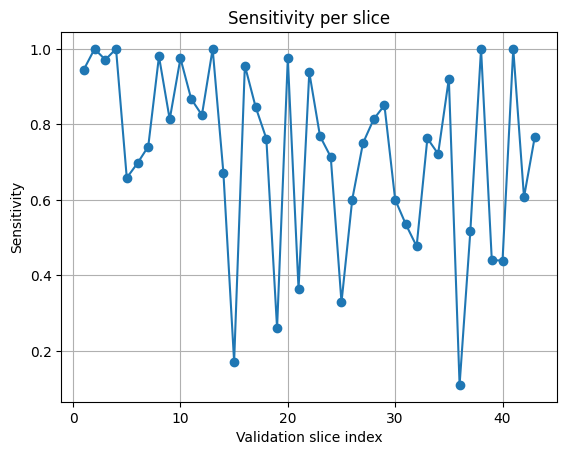


🟢 Validation scores
  Dice          mean = 0.5333   last‑slice = 0.7008
  F1            mean = 0.5333   last‑slice = 0.7008
  Specificity   mean = 0.9241   last‑slice = 0.9523
  Sensitivity   mean = 0.7243   last‑slice = 0.7664


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── choose the populated dict ─────────────────────────────────
metrics_src = history       # we know this one has 43 entries

# pretty labels for the plot / printout
key_map = {"dice": "Dice",
           "f1": "F1",
           "spec": "Specificity",
           "sens": "Sensitivity"}

# X‑axis: slice index 1 … 43
x_axis = range(1, len(next(iter(metrics_src.values()))) + 1)

# ── 1.  PLOTS ────────────────────────────────────────────────
for raw_key, pretty in key_map.items():
    y = metrics_src[raw_key]
    plt.figure()
    plt.plot(x_axis, y, marker="o")
    plt.xlabel("Validation slice index")
    plt.ylabel(pretty)
    plt.title(f"{pretty} per slice")
    plt.grid(True)
    plt.show()

# ── 2.  PRINT FINAL + MEAN SCORES ────────────────────────────
print("\n🟢 Validation scores")
for raw_key, pretty in key_map.items():
    vals = metrics_src[raw_key]
    print(f"  {pretty:<12}  mean = {np.mean(vals):.4f}   last‑slice = {vals[-1]:.4f}")


Best Dice slice  : idx 10, Dice = 0.8535
Worst Dice slice : idx 1, Dice = 0.0000


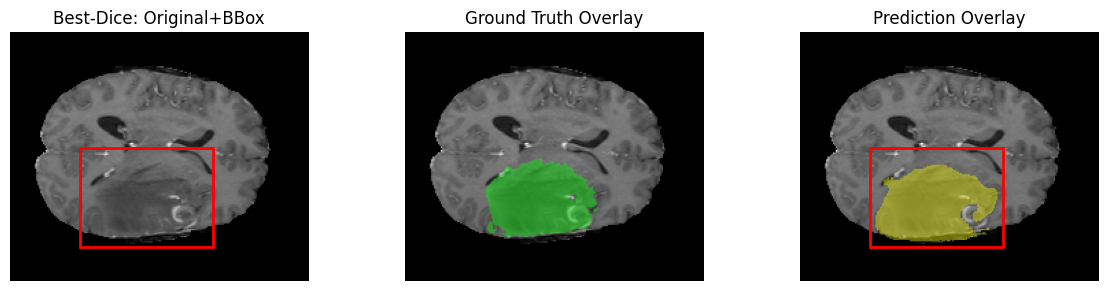

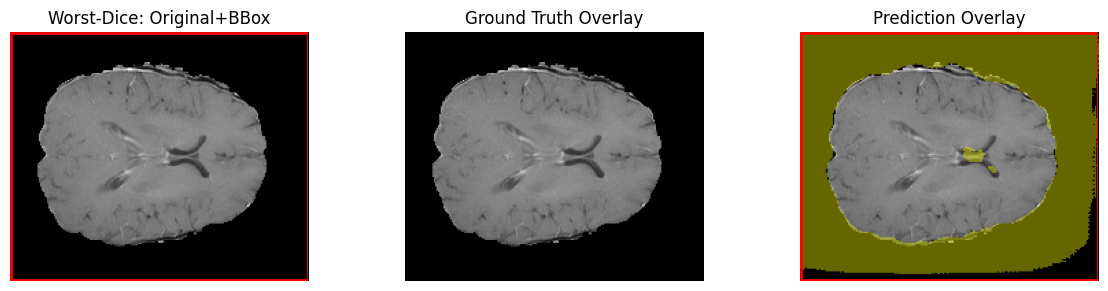

In [ ]:
# ---------------------------------------------------------------------------
#  Visualise highest‑Dice and lowest‑Dice validation slices
#  Prereqs:
#    • `dataset`         – instance of BrainTumorSliceDatasetV2
#    • `history["dice"]` – list of per‑slice Dice scores (len == len(dataset))
#    • `predictor`       – SamPredictor loaded with MedSAM weights
#    • helper `overlay()` and `mask_to_bbox()` from earlier cells
# ---------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---------- find indices ----------
dice_scores = history["dice"]
idx_best = int(np.argmax(dice_scores))
idx_worst = int(np.argmin(dice_scores))

print(f"Best Dice slice  : idx {idx_best}, Dice = {dice_scores[idx_best]:.4f}")
print(f"Worst Dice slice : idx {idx_worst}, Dice = {dice_scores[idx_worst]:.4f}")

def show_slice(idx, title_prefix):
    # --- load tensors ---
    img_t, msk_t, box_t = dataset[idx]
    img_np  = img_t[0].numpy()
    msk_np  = msk_t[0].numpy().astype(bool)
    bbox    = box_t[0].numpy()          # x1,y1,x2,y2

    # --- SAM prediction ---
    img_rgb = (np.stack([img_np]*3, -1) * 255).astype(np.uint8)
    predictor.set_image(img_rgb)
    pred_mask, _, _ = predictor.predict(box=bbox, multimask_output=False)
    pred_np = pred_mask[0]

    # --- overlays ---
    def overlay(img, mask, color=(1,1,0), alpha=0.4):
        out = np.stack([img]*3, -1)
        for c in range(3):
            out[..., c] = np.where(mask,
                                   out[..., c]*(1-alpha) + alpha*color[c],
                                   out[..., c])
        return out

    gt_ov   = overlay(img_np,  msk_np, color=(0,1,0))   # green
    pred_ov = overlay(img_np, pred_np, color=(1,1,0))   # yellow

    # --- plot ---
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    # original + bbox
    axes[0].imshow(img_np, cmap='gray')
    axes[0].add_patch(patches.Rectangle((bbox[0], bbox[1]),
                                        bbox[2]-bbox[0], bbox[3]-bbox[1],
                                        linewidth=2, edgecolor='red', facecolor='none'))
    axes[0].set_title(f"{title_prefix}: Original+BBox")

    # ground truth
    axes[1].imshow(gt_ov)
    axes[1].set_title("Ground Truth Overlay")

    # prediction
    axes[2].imshow(pred_ov)
    axes[2].add_patch(patches.Rectangle((bbox[0], bbox[1]),
                                        bbox[2]-bbox[0], bbox[3]-bbox[1],
                                        linewidth=2, edgecolor='red', facecolor='none'))
    axes[2].set_title("Prediction Overlay")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# ---------- display best & worst ----------
show_slice(idx_best,  "Best‑Dice")
show_slice(idx_worst, "Worst‑Dice")


Top‑2 Dice slices:
  1. idx 10   Dice = 0.8535
  2. idx 0    Dice = 0.8075


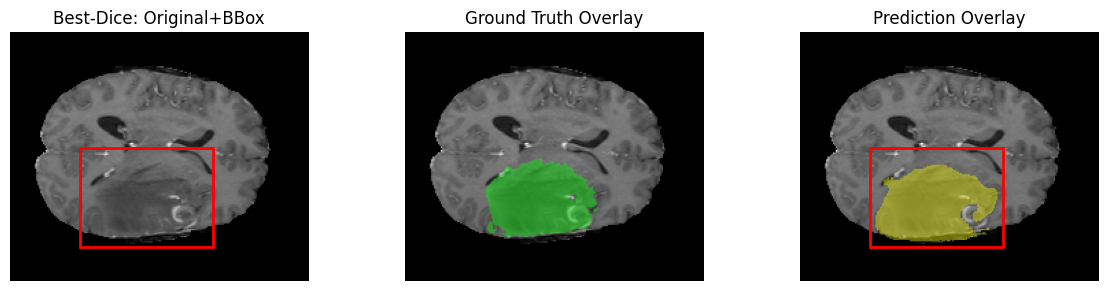

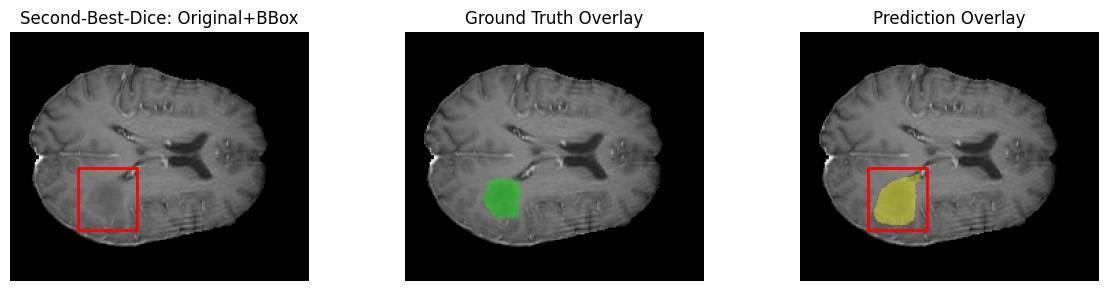

In [ ]:
# ---------------------------------------------------------------------------
#  Visualise the two BEST Dice‑score validation slices
#  (assumes `dataset`, `history["dice"]`, `predictor`, `overlay()` exist)
# ---------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---------- find top‑2 Dice indices ----------
dice_scores = np.array(history["dice"])
top2_idx = dice_scores.argsort()[-2:][::-1]    # best, second‑best
labels   = ["Best‑Dice", "Second‑Best‑Dice"]

print("Top‑2 Dice slices:")
for rank, idx in enumerate(top2_idx, 1):
    print(f"  {rank}. idx {idx:<3}  Dice = {dice_scores[idx]:.4f}")

# ---------- helper to plot one slice ----------
def show_slice(idx, title_prefix):
    img_t, msk_t, box_t = dataset[idx]
    img_np  = img_t[0].numpy()
    msk_np  = msk_t[0].numpy().astype(bool)
    bbox    = box_t[0].numpy()

    # ---- SAM prediction ----
    img_rgb = (np.stack([img_np]*3, -1) * 255).astype(np.uint8)
    predictor.set_image(img_rgb)
    pred_mask, _, _ = predictor.predict(box=bbox, multimask_output=False)
    pred_np = pred_mask[0]

    # ---- overlays ----
    def overlay(img, mask, color=(1,1,0), alpha=0.4):
        out = np.stack([img]*3, -1)
        for c in range(3):
            out[..., c] = np.where(
                mask,
                out[..., c]*(1-alpha) + alpha*color[c],
                out[..., c]
            )
        return out

    gt_ov   = overlay(img_np,  msk_np, color=(0,1,0))
    pred_ov = overlay(img_np, pred_np, color=(1,1,0))

    # ---- plot ----
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    axes[0].imshow(img_np, cmap='gray')
    axes[0].add_patch(patches.Rectangle((bbox[0], bbox[1]),
                                        bbox[2]-bbox[0], bbox[3]-bbox[1],
                                        linewidth=2, edgecolor='red', facecolor='none'))
    axes[0].set_title(f"{title_prefix}: Original+BBox")

    axes[1].imshow(gt_ov);   axes[1].set_title("Ground Truth Overlay")
    axes[2].imshow(pred_ov); axes[2].add_patch(
        patches.Rectangle((bbox[0], bbox[1]),
                          bbox[2]-bbox[0], bbox[3]-bbox[1],
                          linewidth=2, edgecolor='red', facecolor='none'))
    axes[2].set_title("Prediction Overlay")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# ---------- display both slices ----------
for idx, label in zip(top2_idx, labels):
    show_slice(idx, label)


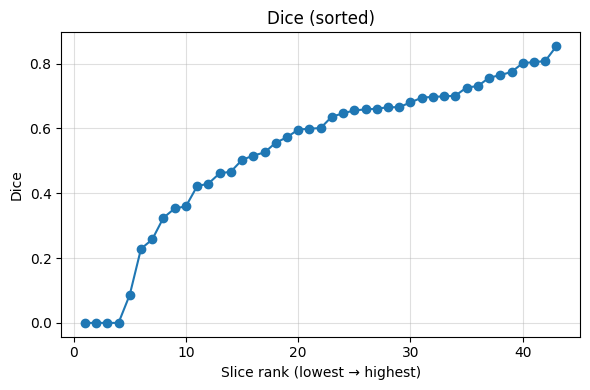

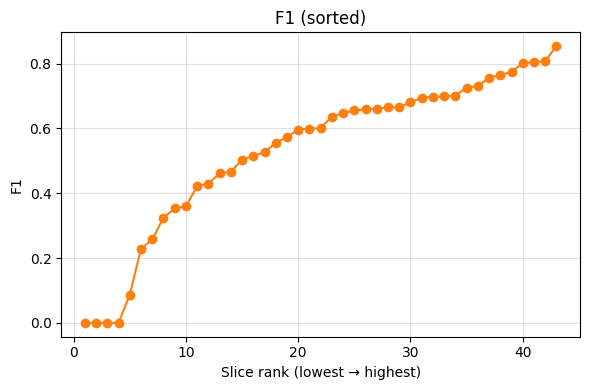

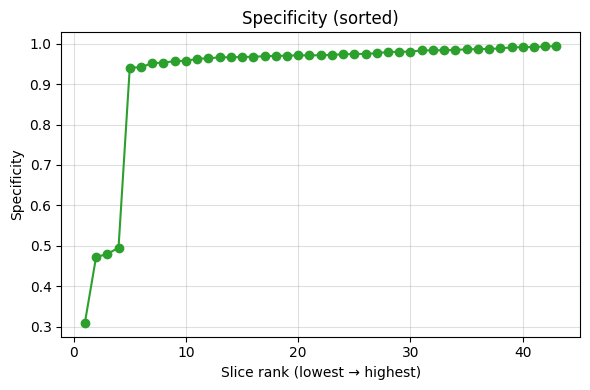

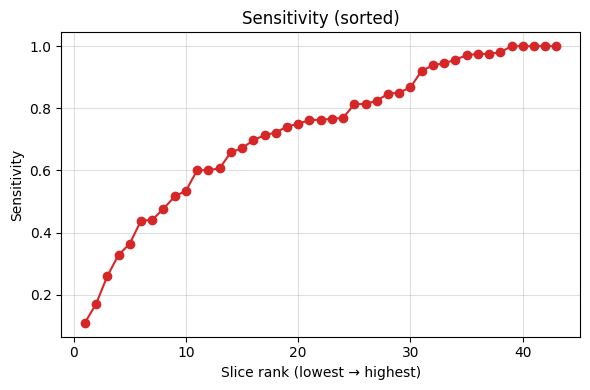

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
#  Sorted‑metric curves (lowest → highest) for Dice, F1, Specificity, Sensitivity
#  Assumes `history` has keys: "dice", "f1", "spec", "sens"
# ------------------------------------------------------------------

metric_info = [
    ("dice", "Dice",           "tab:blue"),
    ("f1",   "F1",             "tab:orange"),
    ("spec", "Specificity",    "tab:green"),
    ("sens", "Sensitivity",    "tab:red"),
]

for raw_key, pretty_name, color in metric_info:
    if raw_key not in history:
        print(f"⚠️  {raw_key} not found in history — skipping.")
        continue

    sorted_vals = np.sort(history[raw_key])          # ascending
    x_axis      = np.arange(1, len(sorted_vals) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(x_axis, sorted_vals, marker="o", color=color)
    plt.xlabel("Slice rank (lowest → highest)")
    plt.ylabel(pretty_name)
    plt.title(f"{pretty_name} (sorted)")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


##Violin Plot

In [ ]:
val_loader = DataLoader(dataset, batch_size=1, shuffle=False)

history = {"dice": [], "f1": [], "spec": [], "sens": []}

sam.eval()
with torch.no_grad():
    for img, msk, box in tqdm(val_loader):
        img_np = img[0, 0].cpu().numpy()
        img_rgb = (np.stack([img_np]*3, -1) * 255).astype(np.uint8)

        predictor.set_image(img_rgb)
        masks, _, _ = predictor.predict(box=box[0].cpu().numpy(),
                                        multimask_output=False)
        pred_np = masks[0]
        gt_np   = msk[0, 0].cpu().numpy().astype(bool)

        dice, f1, spec, sens = compute_metrics(pred_np, gt_np)
        history["dice"].append(dice)
        history["f1"].append(f1)
        history["spec"].append(spec)
        history["sens"].append(sens)


100%|██████████| 43/43 [00:26<00:00,  1.61it/s]


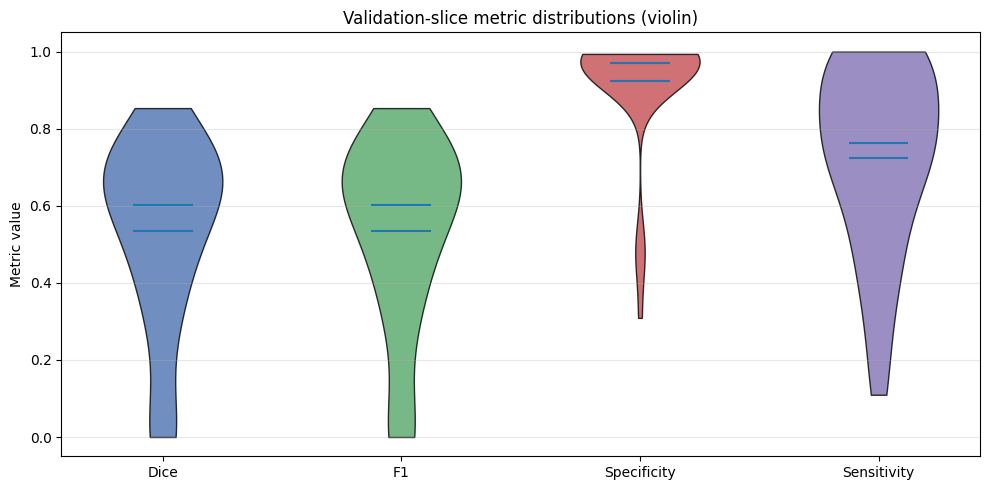

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metric_order = [
    ("dice", "Dice"),
    ("f1",   "F1"),
    ("spec", "Specificity"),
    ("sens", "Sensitivity"),
]
data   = [history[k] for k, _ in metric_order]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]

plt.figure(figsize=(10, 5))
parts = plt.violinplot(
    data,
    showmeans=True,
    showmedians=True,
    showextrema=False
)

for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.8)

plt.xticks(
    ticks=np.arange(1, len(metric_order) + 1),
    labels=[name for _, name in metric_order]
)
plt.ylabel("Metric value")
plt.title("Validation‑slice metric distributions (violin)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
